# Jump Parameter Estimation for M2

1. Define jumps as daily Brent returns below threshold
2. Fit logistic: OVX to P(jump in next 21 days)
3. Calibrate single-parameter eta from empirical jump sizes
4. Final mapping: `ovx_to_jump_params(ovx)` returns (lambda, mu_J, sigma_J)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Load & Merge Data

In [11]:
oil_price = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
ovx = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')

oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date'] = pd.to_datetime(ovx['date'], errors='coerce')

df = pd.merge(oil_price, ovx, on='date', how='inner').sort_values('date').reset_index(drop=True)
df.ffill(inplace=True)

price_col = 'price' if 'price' in df.columns else df.columns[1]
df['oil_ret_1d'] = np.log(df[price_col] / df[price_col].shift(1))
df.dropna(inplace=True)

print(f"Sample: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Observations: {len(df)}")

Sample: 2007-05-11 to 2025-01-01
Observations: 4604


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_44688/2343605539.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


## 2. Define Jumps & Forward-Looking Variables

In [12]:
JUMP_THRESHOLD = -0.05
FORWARD_WINDOW = 21  # trading days

df['is_jump'] = (df['oil_ret_1d'] < JUMP_THRESHOLD).astype(int)

# For each day, look forward 21 days:
#   - did any jump occur?
#   - what was the worst return?
df['any_jump_next21'] = (
    df['is_jump']
    .rolling(window=FORWARD_WINDOW)
    .max()
    .shift(-FORWARD_WINDOW)
)
df['min_ret_next21'] = (
    df['oil_ret_1d']
    .rolling(window=FORWARD_WINDOW)
    .min()
    .shift(-FORWARD_WINDOW)
)

print(f"Total jump days (< {JUMP_THRESHOLD:.0%}): {df['is_jump'].sum()}")
print(f"Jump frequency: {df['is_jump'].mean():.4f} ({df['is_jump'].mean()*252:.1f} per year)")

Total jump days (< -5%): 82
Jump frequency: 0.0178 (4.5 per year)


## 3. Fit Logistic: OVX to P(jump in next 21 days)

In [13]:
def logistic(x, a, b):
    return 1 / (1 + np.exp(-(a * x + b)))

fit_df = df.dropna(subset=['OVXCLS', 'any_jump_next21', 'min_ret_next21']).copy()

# Bin OVX into fine grid to avoid overfitting to individual days
fit_df['ovx_bin'] = pd.cut(fit_df['OVXCLS'], bins=50)
binned = fit_df.groupby('ovx_bin', observed=True).agg(
    ovx_mid=('OVXCLS', 'mean'),
    prob=('any_jump_next21', 'mean'),
    n=('any_jump_next21', 'count'),
).dropna()

popt_lam, _ = curve_fit(
    logistic, binned['ovx_mid'], binned['prob'],
    p0=[0.05, -2], sigma=1/np.sqrt(binned['n']), maxfev=5000
)

a_fit, b_fit = popt_lam
print(f"Logistic fit: a = {a_fit:.4f}, b = {b_fit:.4f}")

Logistic fit: a = 0.0800, b = -4.4801


## 4. Calibrate eta (single jump size parameter)

Exponential jump distribution: one parameter eta controls both mean and variance.
- mu_J = -eta (mean jump size)
- sigma_J = eta (jump size dispersion)

In [14]:
# Conditional on a jump occurring in the next 21 days,
# what is the average worst daily return?
jumped = fit_df[fit_df['any_jump_next21'] == 1].copy()

# eta = mean absolute jump size
eta = -jumped['min_ret_next21'].mean()

print(f"eta = {eta:.4f}")
print(f"  -> mu_J = {-eta:.4f}")
print(f"  -> sigma_J = {eta:.4f}")
print(f"  (calibrated from {len(jumped)} observations with jumps)")

# For comparison: two-parameter estimates
mu_two_param = jumped['min_ret_next21'].mean()
sigma_two_param = jumped['min_ret_next21'].std()
print(f"\nTwo-parameter comparison:")
print(f"  mu_J = {mu_two_param:.4f}, sigma_J = {sigma_two_param:.4f}")

eta = 0.0793
  -> mu_J = -0.0793
  -> sigma_J = 0.0793
  (calibrated from 987 observations with jumps)

Two-parameter comparison:
  mu_J = -0.0793, sigma_J = 0.0615


## 5. Final Mapping Function

In [22]:
OVX_FLOOR = 0  # below this, no jumps

def ovx_to_jump_params(ovx_val):
    """Maps OVX to (lambda, mu_J, sigma_J) using logistic intensity + exponential jump size."""
    if np.isnan(ovx_val) or ovx_val < OVX_FLOOR:
        return 0.0, 0.0, 0.0

    prob = logistic(ovx_val, a_fit, b_fit)
    lam = -np.log(1 - np.clip(prob, 0, 0.999))

    return lam, -eta, eta

## 6. Parameter Table

In [26]:
print(f"{'OVX':>6s} {'lam':>8s} {'prob':>8s} {'mu_J':>8s} {'sig_J':>8s}")
for ovx_val in [25, 30, 35, 40, 50, 60, 80, 100, 150, 200]:
    l, m, s = ovx_to_jump_params(ovx_val)
    prob = 1 - np.exp(-l) if l > 0 else 0
    print(f"{ovx_val:6.0f} {l:8.3f} {prob:8.1%} {m:8.4f} {s:8.4f}")

   OVX      lam     prob     mu_J    sig_J
    25    0.080     7.7%  -0.0793   0.0793
    30    0.118    11.1%  -0.0793   0.0793
    35    0.171    15.7%  -0.0793   0.0793
    40    0.245    21.7%  -0.0793   0.0793
    50    0.481    38.2%  -0.0793   0.0793
    60    0.864    57.9%  -0.0793   0.0793
    80    2.053    87.2%  -0.0793   0.0793
   100    3.544    97.1%  -0.0793   0.0793
   150    6.908    99.9%  -0.0793   0.0793
   200    6.908    99.9%  -0.0793   0.0793


## 7. Visualize

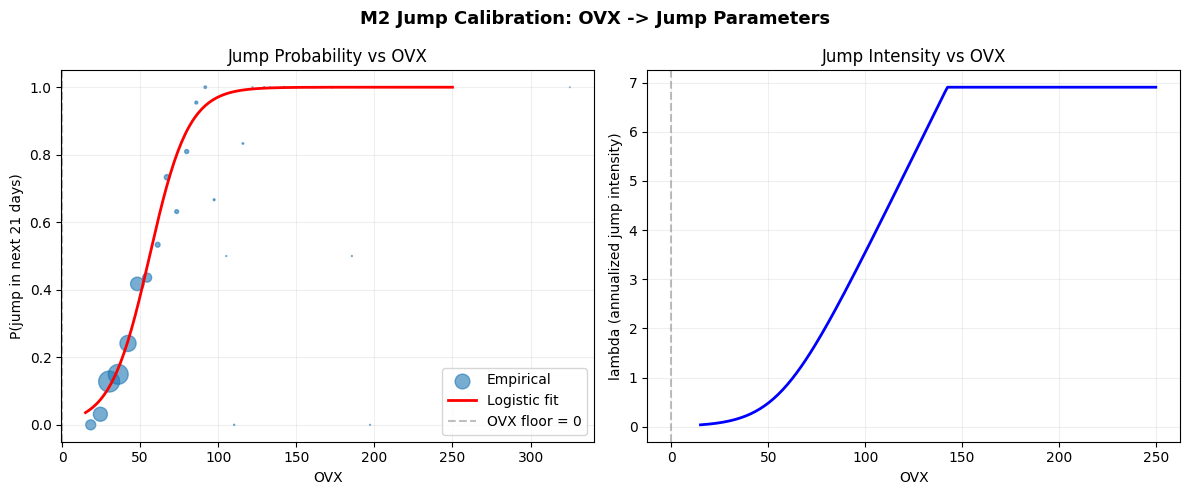

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Logistic fit
ovx_grid = np.linspace(15, 250, 200)
ax = axes[0]
ax.scatter(binned['ovx_mid'], binned['prob'], s=binned['n']/5, alpha=0.6, label='Empirical')
ax.plot(ovx_grid, logistic(ovx_grid, a_fit, b_fit), 'r-', lw=2, label='Logistic fit')
ax.axvline(OVX_FLOOR, color='gray', ls='--', alpha=0.5, label=f'OVX floor = {OVX_FLOOR}')
ax.set_xlabel('OVX')
ax.set_ylabel('P(jump in next 21 days)')
ax.set_title('Jump Probability vs OVX')
ax.legend()
ax.grid(True, alpha=0.2)

# Plot 2: Lambda vs OVX
ax = axes[1]
lam_grid = [ovx_to_jump_params(v)[0] for v in ovx_grid]
ax.plot(ovx_grid, lam_grid, 'b-', lw=2)
ax.axvline(OVX_FLOOR, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('OVX')
ax.set_ylabel('lambda (annualized jump intensity)')
ax.set_title('Jump Intensity vs OVX')
ax.grid(True, alpha=0.2)

fig.suptitle('M2 Jump Calibration: OVX -> Jump Parameters', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('jump_calibration.png', dpi=150, bbox_inches='tight')
plt.show()